## Graphical Causal Models


Una explicación intuitiva: un grafo causal es como un mapa de tuberías que muestra cómo los efectos (asociaciones) fluyen entre variables; entender el mapa nos permite decidir dónde «taponear» o «abrir» para estimar efectos causales.

- Introducción a modelos gráficos: qué son los nodos y aristas, cómo representan relaciones causales y cómo la estructura del grafo guía la interpretación.
- Flujo de asociaciones: cómo una flecha transmite dependencia, cómo se forman caminos dirigidos y no dirigidos, y cuándo un camino transmite asociación observacional.
- Consultas sobre el grafo con software: usar librerías (p. ej., NetworkX, DoWhy) para dibujar DAGs, detectar caminos y evaluar criterios de identificación.
- Identificación revisitada: usar el criterio de back‑door/front‑door en el grafo para decidir qué variables condicionar y cuándo el efecto causal es identificable.
- Dos fuentes comunes de sesgo:
    - Confusión (confounders): estructura que abre caminos espurios; solución típica: condicionar para bloquear el back‑door.
    - Colisionador (collider bias): estructura donde condicionar crea asociación espuria; solución: evitar ajustar por colisionadores (o usar métodos que los eviten).


In [1]:
import polars as pl
import numpy as np

In [2]:
data = pl.read_csv("../data/cross_sell_email.csv")
data

gender,cross_sell_email,age,conversion
i64,str,i64,i64
0,"""short""",15,0
1,"""short""",27,0
1,"""long""",17,0
1,"""long""",34,0
1,"""no_email""",14,0
…,…,…,…
0,"""long""",18,0
1,"""no_email""",16,0
0,"""no_email""",15,0


Un nodo 'U'representa aquellas variables no observadas que pueden influir en las variables observadas del modelo.

Los **DAGs** (grafos dirigidos acíclicos) son representaciones gráficas que muestran relaciones causales. Son dirigidos porque las aristas tienen una dirección, indicando la causalidad de una variable hacia otra. Son acíclicos porque no contienen ciclos, reflejando que la causalidad no es reversible.

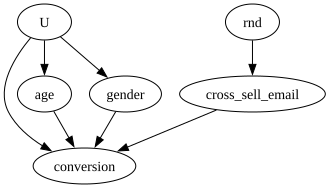

In [3]:
import graphviz as gr

g_cross_sell = gr.Digraph()

g_cross_sell.edge("U", "conversion")
g_cross_sell.edge("U", "age")
g_cross_sell.edge("U", "gender")

g_cross_sell.edge("rnd", "cross_sell_email")
g_cross_sell.edge("cross_sell_email", "conversion")
g_cross_sell.edge("age", "conversion")
g_cross_sell.edge("gender", "conversion")

g_cross_sell

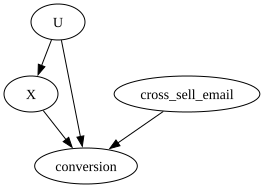

In [4]:
import graphviz as gr

g_cross_sell = gr.Digraph()

g_cross_sell.edge("U", "X")
g_cross_sell.edge("U", "conversion")

g_cross_sell.edge("cross_sell_email", "conversion")
g_cross_sell.edge("X", "conversion")

g_cross_sell

## Are Consultants Worth It?

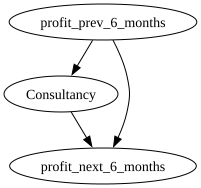

In [5]:
import graphviz as gr

g_cross_sell = gr.Digraph()

g_cross_sell.edge("profit_prev_6_months", "Consultancy")
g_cross_sell.edge("Consultancy", "profit_next_6_months")
g_cross_sell.edge("profit_prev_6_months", "profit_next_6_months")

g_cross_sell

# Crash Course in Graphical Models

## Chains

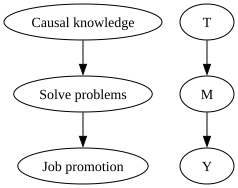

In [6]:
import graphviz as gr

# Creamos un nuevo DAG para la cadena causal
g_chain = gr.Digraph()

# Añadimos los nodos y las relaciones de la cadena causal
g_chain.edge("Causal knowledge", "Solve problems")
g_chain.edge("Solve problems", "Job promotion")

# También mostramos la notación genérica
g_chain.edge("T", "M")
g_chain.edge("M", "Y")

g_chain

Cuando dos variables están asociadas, decimos que son dependientes o no independientes. En notación matemática, esto se expresa así:

$$
T \not\!\perp\!\!\!\perp Y
$$


Para indicar que estamos condicionando en un nodo dentro de un DAG, solemos sombrear ese nodo en el grafo. Esto representa que hemos observado o fijado el valor de esa variable, lo que puede bloquear caminos de asociación entre otras variables.

En notación matemática, la independencia condicional se expresa así:

$$
T \perp\!\!\!\perp Y \mid M
$$

Esto se lee como: “$T$ es independiente de $Y$ dado $M$”.



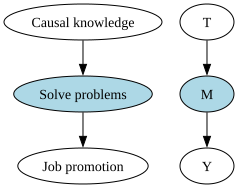

In [7]:
import graphviz as gr

# Creamos un nuevo DAG para la cadena causal
g_chain = gr.Digraph()

# Añadimos los nodos y las relaciones de la cadena causal
g_chain.edge("Causal knowledge", "Solve problems")
g_chain.edge("Solve problems", "Job promotion")

# También mostramos la notación genérica
g_chain.edge("T", "M")
g_chain.edge("M", "Y")

# Sombreamos los nodos que
g_chain.node("M", style="filled", fillcolor="lightblue")
g_chain.node("Solve problems", style="filled", fillcolor="lightblue")

g_chain

## Forks

>Cuando una variable causa dos variables, creando una estructura en forma de horquilla, la variable causante se le llama 'confounder' (confusor). En este caso, la variable confusora puede crear una asociación espuria entre las dos variables causadas.

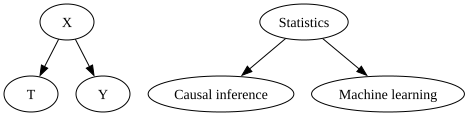

In [8]:
import graphviz as gr

# Creamos el DAG básico con un confusor (estructura de "fork")
g_simple = gr.Digraph()

# X es el confusor, T el tratamiento, Y el resultado
g_simple.edge("X", "T")  # X → T (el confusor afecta al tratamiento)
g_simple.edge("X", "Y")  # X → Y (el confusor afecta al resultado)

g_simple.edge("Statistics", "Causal inference")  
g_simple.edge("Statistics", "Machine learning") 

g_simple

**Ejemplo intuitivo de confusión (confounder):**

- $X$: Nivel socioeconómico  
- $T$: Probabilidad de ir a la universidad  
- $Y$: Ingreso futuro  

Ambos $T$ y $Y$ dependen de $X$. Si no conoces $X$, observarás que $T$ y $Y$ están correlacionados.  
Pero si comparas solo personas con el mismo nivel socioeconómico (condicionas en $X$), la relación entre $T$ y $Y$ desaparece: cualquier asociación era debida a $X$.

En notación de independencia condicional:

$$
T \perp\!\!\!\perp Y \mid X
$$

Es decir, $T$ es independiente de $Y$ dado $X$.

## Immorality or Collider

Una **inmoralidad** (o *collider*) ocurre cuando dos variables ($A$ y $B$) apuntan a una tercera ($C$), pero $A$ y $B$ no están conectadas entre sí.  
Formalmente: $A \rightarrow C \leftarrow B$.  
Condicionar en el colisionador ($C$) puede inducir una asociación espuria entre $A$ y $B$, incluso si son independientes marginalmente.

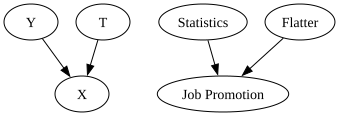

In [9]:
import graphviz as gr

# Creamos el DAG básico con un confusor (estructura de "fork")
g_simple = gr.Digraph()

# X es el confusor, T el tratamiento, Y el resultado
g_simple.edge("Y", "X")  
g_simple.edge("T", "X")  

g_simple.edge("Statistics", "Job Promotion")  
g_simple.edge("Flatter", "Job Promotion") 

g_simple

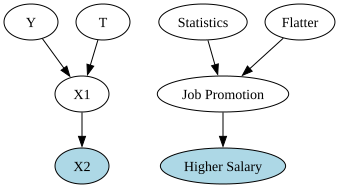

In [10]:
import graphviz as gr

# Creamos el DAG básico con un confusor (estructura de "fork")
g_simple = gr.Digraph()

# X es el confusor, T el tratamiento, Y el resultado
g_simple.edge("Y", "X1")  
g_simple.edge("T", "X1")  
g_simple.edge("X1", "X2")  

g_simple.edge("Statistics", "Job Promotion")  
g_simple.edge("Flatter", "Job Promotion") 
g_simple.edge("Job Promotion", "Higher Salary") 

g_simple.node("X2", style="filled", fillcolor="lightblue")
g_simple.node("Higher Salary", style="filled", fillcolor="lightblue")

g_simple

## The Flow of Association Cheat Sheet


- **Cadena (T → M → Y):** Condicionar en el nodo intermedio (M) bloquea la asociación entre T y Y.
- **Fork/confounder (X → T, X → Y):** Condicionar en el confusor (X) bloquea la asociación entre T y Y.
- **Colisionador (T → X ← Y):** Condicionar en el colisionador (X) o en sus descendientes abre la asociación entre T y Y (¡no condicionar si quieres estimar efectos causales!).
- **Regla general:**
    - Un camino está bloqueado si contiene un no-colisionador condicionado, o un colisionador no condicionado (ni sus descendientes).
    - Un camino está abierto si todos los no-colisionadores NO están condicionados y todos los colisionadores SÍ están condicionados (o alguno de sus descendientes).
- **d-separación:** Si todos los caminos entre dos nodos están bloqueados, las variables son independientes dado el conjunto condicionado.
- **Tip práctico:** Usa software (DoWhy, networkx, dagitty) para verificar d-separación y decidir qué variables ajustar.

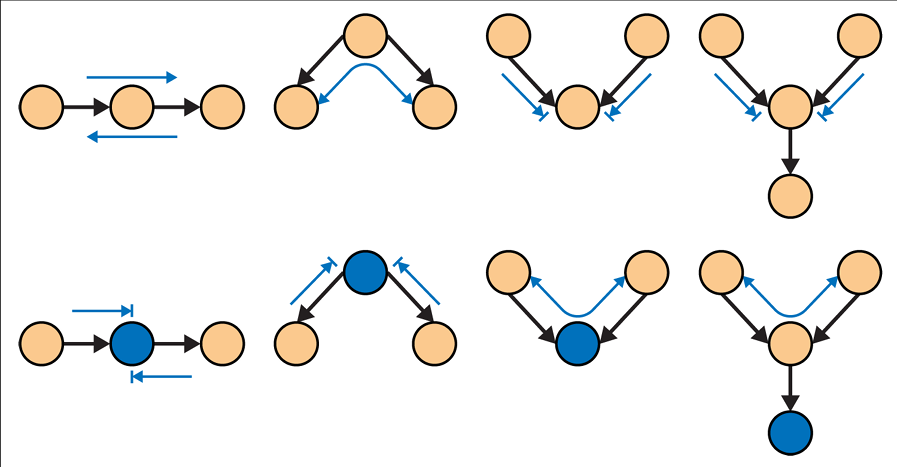

# Querying a Graph in Python

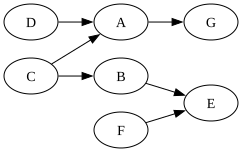

In [11]:
g = gr.Digraph(graph_attr={"rankdir": "LR"})
g.edge("C", "A")
g.edge("C", "B")
g.edge("D", "A")
g.edge("B", "E")
g.edge("F", "E")
g.edge("A", "G")

g

In [12]:
import networkx as nx

model = nx.DiGraph([
    ("C", "A"),
    ("C", "B"),
    ("D", "A"),
    ("B", "E"),
    ("F", "E"),
    ("A", "G"),
])

In [13]:
print("Are D and C dependent?")
print(not nx.is_d_separator(model, {"D"}, {"C"}, set()))

print("Are D and C dependent given A?")
print(not nx.is_d_separator(model, {"D"}, {"C"}, {"A"}))

print("Are D and C dependent given G?")
print(not nx.is_d_separator(model, {"D"}, {"C"}, {"G"}))


Are D and C dependent?
False
Are D and C dependent given A?
True
Are D and C dependent given G?
True


In [14]:
print("Are G and D dependent?")
print(not nx.is_d_separator(model, {"G"}, {"D"}, set()))
print("Are G and D dependent given A?")
print(not nx.is_d_separator(model, {"G"}, {"D"}, {"A"}))

Are G and D dependent?
True
Are G and D dependent given A?
False


In [15]:
print("Are A and B dependent?")
print(not nx.is_d_separator(model, {"A"}, {"B"}, set()))
print("Are A and B dependent given C?")
print(not nx.is_d_separator(model, {"A"}, {"B"}, {"C"}))

Are A and B dependent?
True
Are A and B dependent given C?
False


In [16]:
print("Are G and F dependent?")
print(not nx.is_d_separator(model, {"G"}, {"F"}, set()))
print("Are G and F dependent given E?")
print(not nx.is_d_separator(model, {"G"}, {"F"}, {"E"}))

Are G and F dependent?
False
Are G and F dependent given E?
True


## Identification Revisited

In [17]:
consultancy_model_severed = nx.DiGraph([
    ("profits_prev_6m", "profits_next_6m"),
    ("profits_prev_6m", "consultancy"),
    # ("consultancy", "profits_next_6m"), # relación causal eliminada
])
not(nx.is_d_separator(consultancy_model_severed,
                     {"consultancy"}, {"profits_next_6m"}, set()))
# Devuelve True: hay un camino no causal abierto (sesgo)

True

## CIA and Adjustment Formula

Agrupar por los confusores $X$ y calcular la media de $Y$ para tratados y no tratados en cada grupo es el corazón de la **fórmula de ajuste** (o "back-door adjustment"). Este procedimiento busca estimar el efecto causal promedio del tratamiento $T$ sobre el resultado $Y$, eliminando el sesgo que introduce $X$.

**¿Por qué funciona?**  
Imagina que $X$ es el nivel socioeconómico, $T$ es ir a la universidad y $Y$ es el ingreso futuro. Si simplemente comparas $Y$ entre quienes fueron y no fueron a la universidad, mezclas personas de distintos $X$, lo que introduce confusión. Al comparar solo dentro de cada grupo de $X$, "igualas" a las personas en lo que respecta al confusor.

**Fórmula matemática (fórmula de ajuste):**
$$
ATE = \sum_{x} \left[ E[Y|T=1, X=x] - E[Y|T=0, X=x] \right] P(X=x)
$$

- $E[Y|T=t, X=x]$: media de $Y$ para tratamiento $t$ en el grupo $X=x$.
- $P(X=x)$: proporción de cada grupo $X=x$ en la población.

**Pasos en pseudocódigo:**
1. Agrupa los datos por $X$.
2. Calcula la media de $Y$ para $T=1$ y $T=0$ en cada grupo.
3. Calcula la diferencia de medias en cada grupo.
4. Promedia esas diferencias, ponderando por la frecuencia de cada grupo $X$.


## An identidication example Data

In [18]:
df = pl.DataFrame(dict(
    profits_prev_6m=[1.0, 1.0, 1.0, 5.0, 5.0, 5.0],
    consultancy=[0, 0, 1, 0, 1, 1],
    profits_next_6m=[1, 1.1, 1.2, 5.5, 5.7, 5.7]),
    strict=False
)
df

profits_prev_6m,consultancy,profits_next_6m
f64,i64,f64
1.0,0,1.0
1.0,0,1.1
1.0,1,1.2
5.0,0,5.5
5.0,1,5.7
5.0,1,5.7


In [19]:
(
    df.filter(pl.col("consultancy") == 1).select(pl.col("profits_next_6m")).mean().item() 
    -
    df.filter(pl.col("consultancy") == 0).select(pl.col("profits_next_6m")).mean().item()
)

1.666666666666667

In [28]:
avg_df = (
    df.group_by(["consultancy", "profits_prev_6m"])
      .agg(pl.col("profits_next_6m").mean())
      .pivot(
          on="consultancy",
          index="profits_prev_6m",
          values="profits_next_6m"
      )
      .select(
          pl.col("profits_prev_6m"),
          (pl.col("1") - pl.col("0")).alias("ATE")
      )
)
avg_df

profits_prev_6m,ATE
f64,f64
5.0,0.2
1.0,0.15


In [29]:
avg_df.select(pl.col("ATE")).mean().item()

0.17500000000000004